In [1]:
import polars as pl
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# Foolproof path resolution: finds the project root whether CWD is root or notebooks/
project_root = Path.cwd()
if project_root.name == "notebooks":
    project_root = project_root.parent

# Define absolute paths based on project root
parquet_path = project_root / "data" / "processed" / "03_constraint_event_durations.parquet"
figures_dir = project_root / "figures"

# Ensure figures directory exists
figures_dir.mkdir(parents=True, exist_ok=True)

# Constants from verified data and YAML
COST_PROXY_GBP_PER_MWH = 164.89
AI_SITE_MW = 100
BATTERY_MW = 50
BATTERY_MWH = 100
IT_HANDOFF_HOURS = 1.0
ROUND_TRIP_EFFICIENCY = 0.85

# Battery SoC constraints
MIN_SOC = 0.10
MAX_SOC = 0.95
USABLE_MWH = BATTERY_MWH * (MAX_SOC - MIN_SOC)  # 85 MWh

print(f"✅ Project root identified: {project_root}")
print("✅ Constants loaded.")

✅ Project root identified: /home/ndrew/scotland-ai-split-zones
✅ Constants loaded.


In [2]:
# Load verified historical events (2023-2024 filtered)
print(f"Loading data from: {parquet_path}")
events = pl.read_parquet(parquet_path).sort("start_time")

print(f"✅ Loaded {len(events)} verified historical constraint events.")

Loading data from: /home/ndrew/scotland-ai-split-zones/data/processed/03_constraint_event_durations.parquet
✅ Loaded 222 verified historical constraint events.


In [3]:
# 2. Simulate AI-only response
print("\n" + "=" * 80)
print("SCENARIO 1: AI-ONLY RESPONSE")
print("=" * 80)

ai_only_captured_mwh = 0.0
ai_only_events_handled = 0

for row in events.iter_rows(named=True):
    duration = row["duration_hours"]
    
    if duration >= IT_HANDOFF_HOURS:
        # AI can respond: captures (duration - 1h) at 100 MW
        captured = (duration - IT_HANDOFF_HOURS) * AI_SITE_MW
        ai_only_captured_mwh += captured
        ai_only_events_handled += 1
    else:
        # AI cannot respond (timescale mismatch): 0 MWh captured
        pass

print(f"Events handled by AI-only: {ai_only_events_handled} / {len(events)}")
print(f"Total MWh captured by AI-only: {ai_only_captured_mwh:,.0f} MWh")
print(f"Annualized (over 2 years): {ai_only_captured_mwh / 2:,.0f} MWh/year")
print(f"Annualized value at £{COST_PROXY_GBP_PER_MWH}/MWh: £{ai_only_captured_mwh / 2 * COST_PROXY_GBP_PER_MWH / 1e6:.1f}M/year")


SCENARIO 1: AI-ONLY RESPONSE
Events handled by AI-only: 163 / 222
Total MWh captured by AI-only: 170,950 MWh
Annualized (over 2 years): 85,475 MWh/year
Annualized value at £164.89/MWh: £14.1M/year


In [4]:
# 3. Simulate AI + BESS response
print("\n" + "=" * 80)
print("SCENARIO 2: AI + 50MW/100MWh BESS RESPONSE")
print("=" * 80)

hybrid_captured_mwh = 0.0
hybrid_events_handled = 0
battery_discharged_mwh = 0.0
battery_recharged_mwh = 0.0  # AC-side energy consumed for charging

# Track battery SoC (start at 95%)
soc_mwh = BATTERY_MWH * MAX_SOC  # 95 MWh

# Track marginal capture by event type
p10_marginal_mwh = 0.0
handoff_marginal_mwh = 0.0

for i, row in enumerate(events.iter_rows(named=True)):
    duration = row["duration_hours"]
    start_time = row["start_time"]
    
    # Calculate recharge since last event (if any)
    if i > 0:
        prev_end_time = events.row(i - 1, named=True)["end_time"]
        gap_hours = (start_time - prev_end_time).total_seconds() / 3600
        
        # Recharge at 50 MW during the gap (up to max SoC)
        # Account for round-trip efficiency: need more AC energy to charge
        recharge_potential_dc = min(gap_hours * BATTERY_MW, (BATTERY_MWH * MAX_SOC) - soc_mwh)
        recharge_potential_ac = recharge_potential_dc / ROUND_TRIP_EFFICIENCY  # AC-side energy consumed
        
        soc_mwh += recharge_potential_dc
        battery_recharged_mwh += recharge_potential_ac  # Track AC-side energy
    
    # Calculate discharge for this event
    if duration < IT_HANDOFF_HOURS:
        # Short event: battery handles entire duration (the P10 win!)
        discharge_needed = duration * BATTERY_MW
    else:
        # Long event: battery covers first 1h (handoff cap)
        discharge_needed = IT_HANDOFF_HOURS * BATTERY_MW  # 50 MWh
    
    # Check if battery has enough capacity
    min_soc_mwh = BATTERY_MWH * MIN_SOC  # 10 MWh
    available_mwh = soc_mwh - min_soc_mwh
    
    if available_mwh >= discharge_needed:
        # Battery can handle it
        soc_mwh -= discharge_needed
        battery_discharged_mwh += discharge_needed
        
        # Calculate total captured (battery + AI)
        if duration < IT_HANDOFF_HOURS:
            # Battery handled entire event at 50 MW
            captured = duration * BATTERY_MW
            p10_marginal_mwh += captured  # This is purely battery-enabled
        else:
            # Battery handled first 1h (50 MWh), AI handled rest (100 MW)
            captured = (IT_HANDOFF_HOURS * BATTERY_MW) + ((duration - IT_HANDOFF_HOURS) * AI_SITE_MW)
            handoff_marginal_mwh += IT_HANDOFF_HOURS * BATTERY_MW  # 50 MWh handoff coverage
        
        hybrid_captured_mwh += captured
        hybrid_events_handled += 1
    else:
        # Battery cannot handle it (insufficient SoC)
        # AI still handles it if duration >= 1h
        if duration >= IT_HANDOFF_HOURS:
            captured = (duration - IT_HANDOFF_HOURS) * AI_SITE_MW
            hybrid_captured_mwh += captured
            hybrid_events_handled += 1

print(f"Events handled by hybrid system: {hybrid_events_handled} / {len(events)}")
print(f"Total MWh captured by hybrid: {hybrid_captured_mwh:,.0f} MWh")
print(f"Annualized (over 2 years): {hybrid_captured_mwh / 2:,.0f} MWh/year")
print(f"Annualized value at £{COST_PROXY_GBP_PER_MWH}/MWh: £{hybrid_captured_mwh / 2 * COST_PROXY_GBP_PER_MWH / 1e6:.1f}M/year")


SCENARIO 2: AI + 50MW/100MWh BESS RESPONSE
Events handled by hybrid system: 222 / 222
Total MWh captured by hybrid: 180,575 MWh
Annualized (over 2 years): 90,288 MWh/year
Annualized value at £164.89/MWh: £14.9M/year


In [5]:
# 4. Calculate marginal value (with breakdown)
print("\n" + "=" * 80)
print("MARGINAL VALUE OF BATTERY (BREAKDOWN)")
print("=" * 80)

marginal_mwh = hybrid_captured_mwh - ai_only_captured_mwh
marginal_value_gbp = marginal_mwh * COST_PROXY_GBP_PER_MWH

print(f"Total marginal MWh: {marginal_mwh:,.0f} MWh")
print(f"  - P10 events (<1h, battery-enabled): {p10_marginal_mwh:,.0f} MWh")
print(f"  - Handoff coverage (≥1h events): {handoff_marginal_mwh:,.0f} MWh")
print(f"Annualized marginal MWh: {marginal_mwh / 2:,.0f} MWh/year")
print(f"Annualized marginal value: £{marginal_value_gbp / 2 / 1e6:.2f}M/year")


MARGINAL VALUE OF BATTERY (BREAKDOWN)
Total marginal MWh: 9,625 MWh
  - P10 events (<1h, battery-enabled): 1,475 MWh
  - Handoff coverage (≥1h events): 8,150 MWh
Annualized marginal MWh: 4,812 MWh/year
Annualized marginal value: £0.79M/year


In [6]:
# 5. Battery utilization stats (with RTE correction)
print("\n" + "=" * 80)
print("BATTERY UTILIZATION STATS (WITH ROUND-TRIP EFFICIENCY)")
print("=" * 80)
print(f"Total discharged (DC-side): {battery_discharged_mwh:,.0f} MWh")
print(f"Total recharged (AC-side): {battery_recharged_mwh:,.0f} MWh")
print(f"Round-trip efficiency: {ROUND_TRIP_EFFICIENCY*100:.0f}%")
print(f"Energy lost to heat: {battery_recharged_mwh - battery_discharged_mwh:,.0f} MWh")
print(f"Annual throughput (DC-side): {battery_discharged_mwh / 2:,.0f} MWh/year")


BATTERY UTILIZATION STATS (WITH ROUND-TRIP EFFICIENCY)
Total discharged (DC-side): 9,625 MWh
Total recharged (AC-side): 11,265 MWh
Round-trip efficiency: 85%
Energy lost to heat: 1,640 MWh
Annual throughput (DC-side): 4,812 MWh/year


In [7]:
# 6. Simple breakeven analysis
print("\n" + "=" * 80)
print("SIMPLE BREAKEVEN ANALYSIS")
print("=" * 80)

# Battery CAPEX (from YAML: £250k/MWh × 100 MWh = £25M)
BATTERY_CAPEX_GBP = 250_000 * BATTERY_MWH
annual_marginal_value = marginal_value_gbp / 2

# Simple payback (no discounting, no O&M)
simple_payback_years = BATTERY_CAPEX_GBP / annual_marginal_value if annual_marginal_value > 0 else float('inf')

print(f"Battery CAPEX: £{BATTERY_CAPEX_GBP / 1e6:.1f}M")
print(f"Annual marginal value (constraint capture only): £{annual_marginal_value / 1e6:.2f}M/year")
print(f"Simple payback period: {simple_payback_years:.1f} years")

if simple_payback_years > 15:
    print("\n⚠️  VERDICT: Battery does NOT breakeven on constraint value alone.")
    print("   The battery must rely on merchant revenue stacking (arbitrage, balancing services)")
    print("   to be investable. This validates the 2-hour duration spec for multi-revenue optionality.")
else:
    print(f"\n✅ VERDICT: Battery breakevens in {simple_payback_years:.1f} years on constraint value alone.")

print("\n" + "=" * 80)
print("SIMULATION COMPLETE")
print("=" * 80)


SIMPLE BREAKEVEN ANALYSIS
Battery CAPEX: £25.0M
Annual marginal value (constraint capture only): £0.79M/year
Simple payback period: 31.5 years

⚠️  VERDICT: Battery does NOT breakeven on constraint value alone.
   The battery must rely on merchant revenue stacking (arbitrage, balancing services)
   to be investable. This validates the 2-hour duration spec for multi-revenue optionality.

SIMULATION COMPLETE


✅ Saved to: /home/ndrew/scotland-ai-split-zones/figures/07_marginal_value_breakdown.png


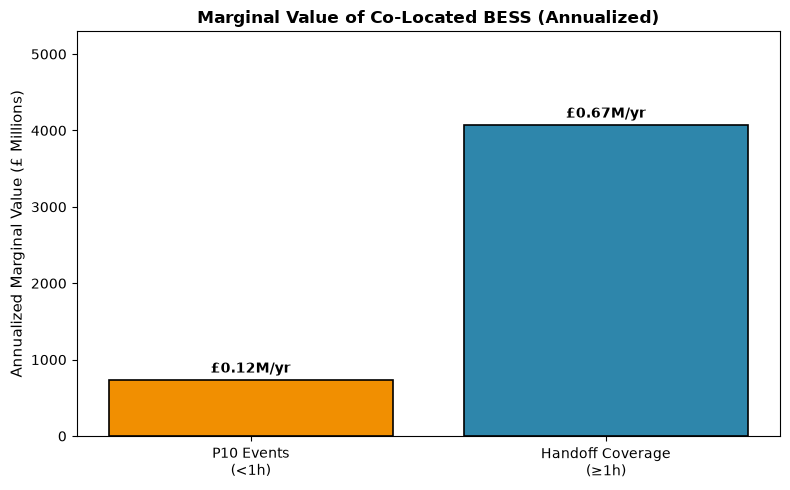

In [8]:
fig, ax = plt.subplots(figsize=(8, 5))

categories = ['P10 Events\n(<1h)', 'Handoff Coverage\n(≥1h)']
values = [p10_marginal_mwh / 2, handoff_marginal_mwh / 2]  # Annualized
colors = ['#F18F01', '#2E86AB']

bars = ax.bar(categories, values, color=colors, edgecolor='black', linewidth=1.2)

# Add value labels
for bar in bars:
    yval = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, yval + 50, f'£{(yval * COST_PROXY_GBP_PER_MWH)/1e6:.2f}M/yr', 
            ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.set_ylabel('Annualized Marginal Value (£ Millions)', fontsize=11)
ax.set_title('Marginal Value of Co-Located BESS (Annualized)', fontsize=12, fontweight='bold')
ax.set_ylim(0, max(values) * 1.3)

plt.tight_layout()

# FOOLPROOF SAVE PATH
out_path = figures_dir / "07_marginal_value_breakdown.png"
plt.savefig(out_path, dpi=300, bbox_inches='tight')
print(f"✅ Saved to: {out_path.resolve()}")
plt.show()

## What This Chart Shows

This chart breaks down the marginal value that a co-located battery adds to a flexible AI training site. In other words: if you already have an AI site that can respond to grid constraints, what extra value does adding a battery actually deliver?

The answer comes in two parts:

1. P10 Events (<1 hour) — £0.12M/year
These are the short constraint events that the AI physically cannot respond to because they're over before the AI can safely checkpoint and ramp down. The battery handles these entirely on its own, capturing value that would otherwise be lost.


This is the "headline" use case for the battery — bridging the timescale mismatch. But as the chart shows, it's actually the smaller source of value.

2. Handoff Coverage (≥1 hour events) — £0.67M/year

This is the less obvious but dominant source of value. For longer constraint events (which make up the majority of the opportunity), the AI still needs about an hour to checkpoint and ramp down.

During that first hour, the grid gets zero relief from the AI.

The battery fills that gap. It provides 50 MW of constraint relief during the first hour of every long event, while the AI prepares to take over. This "handoff coverage" captures 5.5× more value than the P10 events alone.


The Strategic Takeaway

The chart reveals that the battery's primary economic role isn't just catching the short events the AI misses — it's smoothing the transition for the long events the AI does handle. The battery acts as a bridge, ensuring the grid gets continuous support from the moment a constraint event starts, rather than waiting an hour for the AI to respond.

However, even combined, these two value streams only add up to £0.79M/year — which is why the battery cannot pay for itself on constraint avoidance alone (31.5-year payback on a £25M investment). The battery must also participate in merchant revenue stacking (arbitrage, balancing services, Capacity Market) to be commercially viable. The AI constraint response is a valuable optimization, not the sole business case.

Note:

For a 100 MW AI site paired with a 50 MW / 100 MWh battery, our model shows the battery captures a marginal upper-bound value of ~£0.79M/year specifically from AI constraint response (£0.12M from short P10 events + £0.67M from 1-hour handoff coverage). Because this is an upper-bound estimate that assumes full 50 MW response for every event, the real-world figure may be slightly lower. Therefore, this AI-specific value is a valuable optimization, but it is insufficient to fund the battery. The battery's primary business case must rely on merchant revenue stacking (arbitrage, Dynamic Containment, Capacity Market).

✅ Saved to: /home/ndrew/scotland-ai-split-zones/figures/07_economic_verdict.png


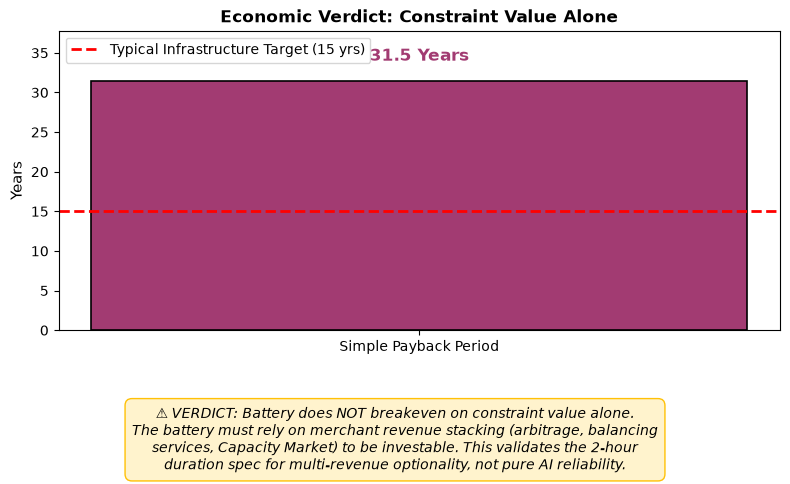

In [9]:
# Recalculate just in case this cell is run independently
marginal_mwh = hybrid_captured_mwh - ai_only_captured_mwh
marginal_value_gbp = marginal_mwh * COST_PROXY_GBP_PER_MWH
annual_marginal_value_gbp = marginal_value_gbp / 2

BATTERY_CAPEX_GBP = 250_000 * BATTERY_MWH  # £25M
simple_payback_years = BATTERY_CAPEX_GBP / annual_marginal_value_gbp if annual_marginal_value_gbp > 0 else float('inf')

fig, ax = plt.subplots(figsize=(8, 5))

# Bar for payback
ax.bar(['Simple Payback Period'], [simple_payback_years], color='#A23B72', edgecolor='black', linewidth=1.2, width=0.4)

# Target line (e.g., 15 years for infrastructure)
ax.axhline(y=15, color='red', linestyle='--', linewidth=2, label='Typical Infrastructure Target (15 yrs)')

ax.text(0, simple_payback_years + 2, f'{simple_payback_years:.1f} Years', ha='center', va='bottom', fontsize=12, fontweight='bold', color='#A23B72')

ax.set_ylabel('Years', fontsize=11)
ax.set_title('Economic Verdict: Constraint Value Alone', fontsize=12, fontweight='bold')
ax.set_ylim(0, max(simple_payback_years * 1.2, 20))
ax.legend(loc='upper left')

# Add verdict text box
verdict_text = (
    "⚠️ VERDICT: Battery does NOT breakeven on constraint value alone.\n"
    "The battery must rely on merchant revenue stacking (arbitrage, balancing\n"
    "services, Capacity Market) to be investable. This validates the 2-hour\n"
    "duration spec for multi-revenue optionality, not pure AI reliability."
)
fig.text(0.5, 0.05, verdict_text, ha='center', fontsize=10, style='italic', 
         bbox=dict(boxstyle='round,pad=0.5', facecolor='#fff3cd', edgecolor='#ffc107'))

plt.tight_layout(rect=[0, 0.25, 1, 1])

# FOOLPROOF SAVE PATH
out_path2 = figures_dir / "07_economic_verdict.png"
plt.savefig(out_path2, dpi=300, bbox_inches='tight')
print(f"✅ Saved to: {out_path2.resolve()}")
plt.show()